# Ensemble Methods

## Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## AdaBoost

AdaBoost builds a strong classifier by combining many weak classifiers sequentially. Each round focuses on the mistakes of the previous round.

**Setup:** Give every training point an equal weight $w_i = 1/N$.

**Repeat for $t = 1 \ldots T$:**

1. **Train a weak learner** $h_t$ on the weighted dataset — the learner tries to do well on points with large weights
2. **Compute weighted error** — the fraction of weight on misclassified points:
$$\varepsilon_t = \sum_i w_i \cdot \mathbf{1}[h_t(x_i) \neq y_i]$$
3. **Compute the learner's vote weight:**
$$\alpha_t = \frac{1}{2} \log\frac{1 - \varepsilon_t}{\varepsilon_t}$$
A learner with low error gets a large positive $\alpha$; one at 50% error gets $\alpha \approx 0$
4. **Update sample weights** — increase weight on misclassified points, decrease on correct ones:
$$w_i \leftarrow w_i \cdot \exp(-\alpha_t \cdot y_i \cdot h_t(x_i))$$
then renormalize so weights sum to 1

**Final classifier:**
$$H(x) = \text{sign}\!\left(\sum_t \alpha_t h_t(x)\right)$$
A weighted majority vote across all $T$ weak learners.

**The key insight:** each round trains on a *reweighted* version of the data, so the next weak learner is forced to focus on whatever the ensemble is currently getting wrong. Misclassified points become "harder" examples that the next stump must pay more attention to.

---

**When to use AdaBoost:**

AdaBoost works well when you have a large dataset with noisy but structured patterns and want a strong classifier built from simple components. It tends to be a good default when:
- Individual features are weak predictors on their own (e.g. decision stumps are near 50% accuracy alone)
- You want an interpretable ensemble — each weak learner is simple and its contribution (α) is explicit
- You can afford sequential training (unlike bagging, rounds cannot be parallelized)

It can overfit on noisy data since later rounds aggressively upweight outliers — in that case, limit T or use a noise-robust variant like GentleBoost.

**Real-world use cases:**
- **Face detection** — the original Viola-Jones face detector (2001) used AdaBoost to select and combine Haar-like features; it was the backbone of camera autofocus for over a decade
- **Medical diagnosis** — combining weak signals from many biomarkers to classify disease vs. healthy
- **Fraud detection** — learning from rare, hard-to-classify fraudulent transactions that get upweighted each round
- **NLP / text classification** — boosting simple word-presence features into a strong document classifier


In [ ]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

np.random.seed(42)

# --- Simple 1D dataset ---
X = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4, 5], dtype=float).reshape(-1, 1)
y = np.array([-1, -1, -1,  1, 1, 1,-1,-1, 1, 1])   # two "blobs" that overlap

N = len(y)
weights = np.ones(N) / N   # uniform initial weights

T = 3   # number of rounds

# --- AdaBoost with decision stumps ---
stumps = []   # (threshold, polarity, alpha)
all_weights = [weights.copy()]

def stump_predict(X, threshold, polarity):
    pred = np.ones(len(X))
    if polarity == 1:
        pred[X.ravel() < threshold] = -1
    else:
        pred[X.ravel() >= threshold] = -1
    return pred

for t in range(T):
    best_err, best_thresh, best_pol = np.inf, None, None

    # search over all midpoints
    thresholds = np.linspace(X.min() - 0.5, X.max() + 0.5, 200)
    for thresh in thresholds:
        for polarity in [1, -1]:
            pred = stump_predict(X, thresh, polarity)
            err  = np.sum(weights[pred != y])
            if err < best_err:
                best_err, best_thresh, best_pol = err, thresh, polarity

    # clip to avoid log(0)
    best_err = np.clip(best_err, 1e-10, 1 - 1e-10)
    alpha = 0.5 * np.log((1 - best_err) / best_err)

    pred = stump_predict(X, best_thresh, best_pol)
    weights = weights * np.exp(-alpha * y * pred)
    weights /= weights.sum()

    stumps.append((best_thresh, best_pol, alpha))
    all_weights.append(weights.copy())
    print(f"Round {t+1}: threshold={best_thresh:.2f}  polarity={best_pol:+d}  "
          f"error={best_err:.3f}  alpha={alpha:.3f}")

# --- Final prediction ---
def adaboost_predict(X, stumps):
    score = np.zeros(len(X))
    for thresh, pol, alpha in stumps:
        score += alpha * stump_predict(X, thresh, pol)
    return np.sign(score)

final_pred = adaboost_predict(X, stumps)
print(f"\nFinal accuracy: {np.mean(final_pred == y):.0%}")


Round 1: threshold=-1.99  polarity=+1  error=0.200  alpha=0.693
Round 2: threshold=3.04  polarity=+1  error=0.188  alpha=0.733
Round 3: threshold=1.03  polarity=-1  error=0.192  alpha=0.718

Final accuracy: 100%


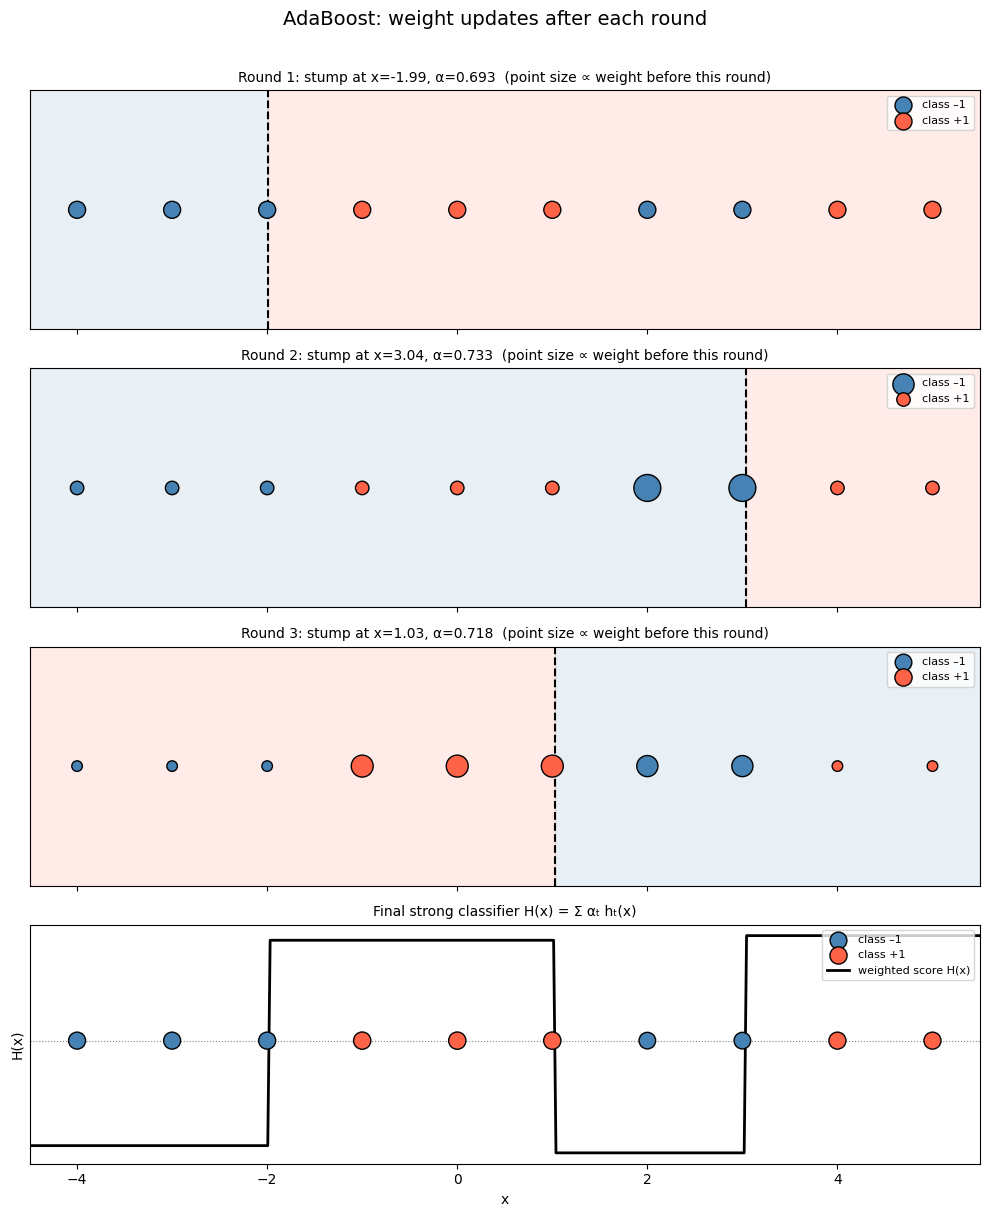

In [ ]:
fig, axes = plt.subplots(T + 1, 1, figsize=(10, 3 * (T + 1)), sharex=True)
fig.suptitle("AdaBoost: weight updates after each round", fontsize=14, y=1.01)

x_line = np.linspace(X.min() - 0.5, X.max() + 0.5, 400).reshape(-1, 1)
colors = {-1: "steelblue", 1: "tomato"}
labels = {-1: "class –1", 1: "class +1"}

cumulative_score = np.zeros(len(x_line))

for t, ax in enumerate(axes):
    w = all_weights[t]
    # scatter: size encodes weight, color encodes class
    for cls in [-1, 1]:
        mask = y == cls
        ax.scatter(
            X[mask], np.zeros(mask.sum()),
            s=w[mask] * 1500,
            color=colors[cls], edgecolors="k", zorder=3,
            label=labels[cls]
        )

    if t < T:
        thresh, pol, alpha = stumps[t]
        # shade the region predicted +1
        if pol == 1:
            ax.axvspan(thresh, x_line.max(), alpha=0.12, color="tomato")
            ax.axvspan(x_line.min(), thresh, alpha=0.12, color="steelblue")
        else:
            ax.axvspan(thresh, x_line.max(), alpha=0.12, color="steelblue")
            ax.axvspan(x_line.min(), thresh, alpha=0.12, color="tomato")

        ax.axvline(thresh, color="k", lw=1.5, ls="--")
        ax.set_title(
            f"Round {t+1}: stump at x={thresh:.2f}, α={alpha:.3f}  "
            f"(point size ∝ weight before this round)",
            fontsize=10
        )
    else:
        # final panel: show the additive score
        score = np.zeros(len(x_line))
        for th, po, al in stumps:
            score += al * stump_predict(x_line, th, po)
        ax.plot(x_line, score, "k-", lw=2, label="weighted score H(x)")
        ax.axhline(0, color="gray", lw=0.8, ls=":")
        ax.set_title("Final strong classifier H(x) = Σ αₜ hₜ(x)", fontsize=10)
        ax.set_ylabel("H(x)")

    ax.set_yticks([])
    ax.set_xlim(x_line.min(), x_line.max())
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("x")
plt.tight_layout()
plt.show()

Training accuracy: 97.5%


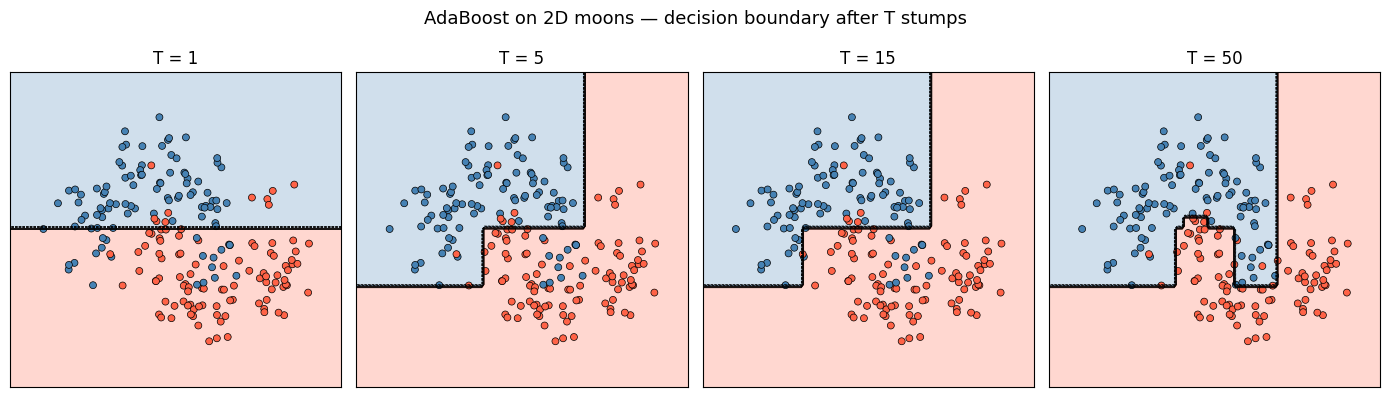

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons

# 2D dataset — two interleaving half-circles
X2, y2 = make_moons(n_samples=200, noise=0.25, random_state=42)
y2 = np.where(y2 == 0, -1, 1)   # convert to ±1

# Train AdaBoost with decision stumps (max_depth=1)
clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)
clf.fit(X2, y2)
print(f"Training accuracy: {clf.score(X2, y2):.1%}")

# --- Plot decision boundary evolution ---
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("AdaBoost on 2D moons — decision boundary after T stumps", fontsize=13)

h = 0.04
xx, yy = np.meshgrid(
    np.arange(X2[:, 0].min() - .5, X2[:, 0].max() + .5, h),
    np.arange(X2[:, 1].min() - .5, X2[:, 1].max() + .5, h),
)
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, T_plot in zip(axes, [1, 5, 15, 50]):
    # partial prediction using only the first T_plot stumps
    score = sum(
        clf.estimator_weights_[t] * clf.estimators_[t].predict(grid)
        for t in range(T_plot)
    )
    Z = np.sign(score).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(["steelblue", "tomato"]))
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5)
    ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap=ListedColormap(["steelblue", "tomato"]),
               edgecolors="k", s=25, linewidths=0.5)
    ax.set_title(f"T = {T_plot}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## Gradient Boosting

Gradient Boosting also builds an ensemble sequentially, but instead of reweighting points, each new weak learner is fit to the **residual errors** of the current ensemble — the directions in which the model is still wrong.

**Setup:** Start with a constant prediction (the mean of the targets):
```
F_0(x) = mean(y)
```

**Repeat for t = 1 ... T:**

1. **Compute residuals** — how far off is the current model on each point?
```
r_i = y_i - F_{t-1}(x_i)
```
2. **Fit a weak learner** `h_t` to the residuals (not the original labels)
3. **Update the model**, scaled by a learning rate `eta`:
```
F_t(x) = F_{t-1}(x) + eta * h_t(x)
```

**Final prediction:**
```
F_T(x) = F_0(x) + eta * h_1(x) + eta * h_2(x) + ... + eta * h_T(x)
```

**The key insight:** each weak learner corrects the mistakes of the ensemble so far. The residual `r_i` is large and positive where the model under-predicted, large and negative where it over-predicted — so fitting `h_t` to residuals nudges the ensemble in the right direction.

The name "gradient boosting" comes from the fact that residuals are the **negative gradient of squared-error loss** — each step is a gradient descent step in function space. This generalizes to other loss functions (log loss, etc.) by substituting the appropriate gradient.

**Compared to AdaBoost:**
- AdaBoost reweights points and uses a weighted vote
- Gradient Boosting fits to residuals and uses an additive sum
- Gradient Boosting naturally extends to regression; AdaBoost is primarily for classification
- Gradient Boosting is more flexible — swap the loss function and the algorithm adapts

**When to use Gradient Boosting:**
- Tabular data — it dominates structured data (XGBoost, LightGBM, CatBoost are all variants)
- When you need regression, not just classification
- When raw accuracy matters more than interpretability of individual trees

**Real-world use cases:**
- **Kaggle / competitions** — GBMs win the majority of tabular data competitions
- **Credit scoring** — predicting probability of loan default
- **Search ranking** — LambdaMART is gradient boosting applied to ranking problems
- **Weather forecasting** — blending many weak meteorological signals


In [7]:
# --- 1D Gradient Boosting from scratch (regression) ---
np.random.seed(0)

x1d = np.linspace(0, 2 * np.pi, 80)
y1d = np.sin(x1d) + np.random.normal(0, 0.2, size=len(x1d))

T      = 5       # number of rounds
eta    = 0.8     # learning rate
X1d    = x1d.reshape(-1, 1)

# simple depth-2 tree as weak learner
from sklearn.tree import DecisionTreeRegressor

F = np.full(len(y1d), y1d.mean())   # F_0 = mean
all_F        = [F.copy()]
all_residuals = []
trees         = []

for t in range(T):
    r = y1d - F                              # residuals
    tree = DecisionTreeRegressor(max_depth=2)
    tree.fit(X1d, r)
    F = F + eta * tree.predict(X1d)          # update
    all_residuals.append(r.copy())
    all_F.append(F.copy())
    trees.append(tree)
    print(f"Round {t+1}  MSE: {np.mean((y1d - F)**2):.4f}")


Round 1  MSE: 0.1061
Round 2  MSE: 0.0427
Round 3  MSE: 0.0354
Round 4  MSE: 0.0308
Round 5  MSE: 0.0293


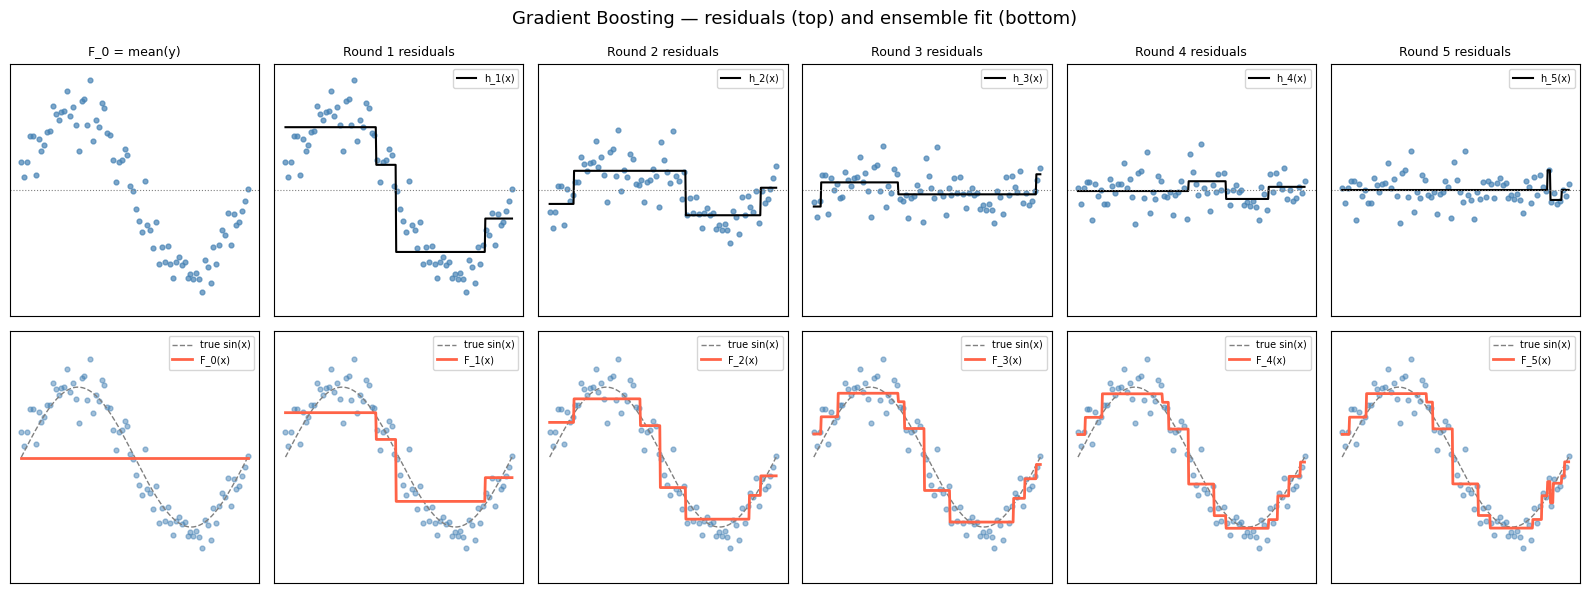

In [8]:
fig, axes = plt.subplots(2, T + 1, figsize=(16, 6))
fig.suptitle("Gradient Boosting — residuals (top) and ensemble fit (bottom)", fontsize=13)

x_plot = np.linspace(0, 2 * np.pi, 400).reshape(-1, 1)

for t in range(T + 1):
    ax_res = axes[0][t]
    ax_fit = axes[1][t]

    if t == 0:
        # before any boosting: residuals are y - mean
        res = y1d - all_F[0]
        ax_res.set_title("F_0 = mean(y)", fontsize=9)
    else:
        res = all_residuals[t - 1]
        ax_res.set_title(f"Round {t} residuals", fontsize=9)
        # show what h_t learned
        h_plot = trees[t - 1].predict(x_plot)
        ax_res.plot(x_plot, h_plot, "k-", lw=1.5, label=f"h_{t}(x)")
        ax_res.legend(fontsize=7)

    ax_res.scatter(x1d, res, s=12, color="steelblue", alpha=0.7)
    ax_res.axhline(0, color="gray", lw=0.8, ls=":")
    ax_res.set_ylim(-1.6, 1.6)
    ax_res.set_xticks([]); ax_res.set_yticks([])

    # ensemble prediction so far
    F_plot = np.full(len(x_plot), y1d.mean())
    for i in range(t):
        F_plot += eta * trees[i].predict(x_plot)

    ax_fit.scatter(x1d, y1d, s=12, color="steelblue", alpha=0.5)
    ax_fit.plot(x_plot, np.sin(x_plot), "gray", lw=1, ls="--", label="true sin(x)")
    ax_fit.plot(x_plot, F_plot, "tomato", lw=2, label=f"F_{t}(x)")
    ax_fit.set_ylim(-1.8, 1.8)
    ax_fit.set_xticks([]); ax_fit.set_yticks([])
    ax_fit.legend(fontsize=7)

plt.tight_layout()
plt.show()
